In [1]:
# load and manipulate the ReplicaCAD_SceneManipulation-v1
import numpy as np
import sapien as sapien
import torch

from mani_skill.agents.robots import Xlerobot
from mani_skill.envs.sapien_env import BaseEnv
from mani_skill.sensors.camera import CameraConfig
from mani_skill.utils import sapien_utils
from mani_skill.utils.registration import register_env
from mani_skill.utils.scene_builder import SceneBuilder
from mani_skill.utils.scene_builder.registration import REGISTERED_SCENE_BUILDERS
from mani_skill.utils.structs.types import GPUMemoryConfig, SimConfig
from typing import Any, Dict

/home/koepf/miniconda3/envs/vltest/lib/python3.12/site-packages/sapien/__init__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/koepf/miniconda3/envs/vltest/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/koepf/miniconda3/envs/vltest/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from mani_skill.utils.building import actors
from mani_skill.utils import common, sapien_utils
from mani_skill.envs.utils import randomization
from mani_skill.utils.structs.pose import Pose

@register_env("KitchenStack-v1", max_episode_steps=200)
class KitchenStackEnv(BaseEnv):
    """
    """

    SUPPORTED_ROBOTS = ["xlerobot"]
    agent: Xlerobot

    def __init__(
        self,
        *args,
        num_envs=1,
        **kwargs
    ):
        scene_builder_cls = REGISTERED_SCENE_BUILDERS["ReplicaCAD"].scene_builder_cls
        self.scene_builder: SceneBuilder = scene_builder_cls(self)
        self.build_config_idxs = [1]
        self.init_config_idxs = None
        if num_envs == 1:
            reconfiguration_freq = 1
        else:
            reconfiguration_freq = 0
        super().__init__(
            *args,
            robot_uids="xlerobot",
            reconfiguration_freq=reconfiguration_freq,
            num_envs=num_envs,
            **kwargs
        )

    @property
    def _default_sim_config(self):
        return SimConfig(
            spacing=50,
            gpu_memory_config=GPUMemoryConfig(
                found_lost_pairs_capacity=2**25,
                max_rigid_patch_count=2**21,
                max_rigid_contact_count=2**23,
            ),
        )

    def reset(self, seed=None, options=None):
        if options is None:
            options = dict(reconfigure=False)
        self._set_episode_rng(seed, options.get("env_idx", torch.arange(self.num_envs)))
        if "reconfigure" in options and options["reconfigure"]:
            self.build_config_idxs = options.get(
                "build_config_idxs", self.build_config_idxs
            )
            self.init_config_idxs = options.get("init_config_idxs", None)
        else:
            assert (
                "build_config_idxs" not in options
            ), "options dict cannot contain build_config_idxs without reconfigure=True"
            self.init_config_idxs = options.get(
                "init_config_idxs", self.init_config_idxs
            )
        if isinstance(self.build_config_idxs, int):
            self.build_config_idxs = [self.build_config_idxs]
        if isinstance(self.init_config_idxs, int):
            self.init_config_idxs = [self.init_config_idxs]
        return super().reset(seed, options)

    def _load_lighting(self, options: dict):
        if self.scene_builder.builds_lighting:
            return
        return super()._load_lighting(options)

    def _load_agent(self, options: dict):
        robot_initial_pose = self.scene_builder.robot_initial_pose
        super()._load_agent(
            options,
            initial_agent_poses=robot_initial_pose,
        )

    def _load_scene(self, options: dict):
        if self.scene_builder.build_configs is not None:
            self.scene_builder.build(
                self.build_config_idxs
                if self.build_config_idxs is not None
                else self.scene_builder.sample_build_config_idxs()
            )
        else:
            self.scene_builder.build()

        self.cube_half_size = common.to_tensor([0.02] * 3, device=self.device)
        self.cubeA = actors.build_cube(
            self.scene,
            half_size=0.02,
            color=[1, 0, 0, 1],
            name="cubeA",
            initial_pose=sapien.Pose(p=[0, 0, 0.1]),
        )
        self.cubeB = actors.build_cube(
            self.scene,
            half_size=0.02,
            color=[0, 1, 0, 1],
            name="cubeB",
            initial_pose=sapien.Pose(p=[1, 0, 0.1]),
        )

    def _initialize_episode(self, env_idx: torch.Tensor, options: dict):
        with torch.device(self.device):
            if self.scene_builder.init_configs is not None:
                self.scene_builder.initialize(
                    env_idx,
                    (
                        self.init_config_idxs
                        if self.init_config_idxs is not None
                        else self.scene_builder.sample_init_config_idxs()
                    ),
                )
            else:
                self.scene_builder.initialize(env_idx)

            # override initial pose
            robot_initial_pose = sapien.Pose(p=[1.874, -5.114, 0.02], q=[1, 0, 0, 0])
            self.scene_builder.env.agent.robot.set_pose(robot_initial_pose)

            # drop cube on table
            b = len(env_idx)
            xyz = torch.zeros((b, 3))
            xyz[:, 2] = 0.7
            xy = torch.rand((b, 2)) * 0.01 - 0.01 + torch.tensor([2.08, -5.114])
            region = [[-0.05, -0.05], [0.05, 0.05]]
            sampler = randomization.UniformPlacementSampler(
                bounds=region, batch_size=b, device=self.device
            )
            radius = torch.linalg.norm(torch.tensor([0.02, 0.02])) + 0.001
            cubeA_xy = xy + sampler.sample(radius, 100)
            cubeB_xy = xy + sampler.sample(radius, 100, verbose=False)

            xyz[:, :2] = cubeA_xy
            qs = randomization.random_quaternions(
                b,
                lock_x=True,
                lock_y=True,
                lock_z=False,
            )
            pA = Pose.create_from_pq(p=xyz.clone(), q=qs)
            self.cubeA.set_pose(pA)
            print("cubeA", pA)

            xyz[:, :2] = cubeB_xy
            qs = randomization.random_quaternions(
                b,
                lock_x=True,
                lock_y=True,
                lock_z=False,
            )
            self.cubeB.set_pose(Pose.create_from_pq(p=xyz, q=qs))


    def evaluate(self) -> dict:
        return dict()

    def compute_dense_reward(self, obs: Any, action: torch.Tensor, info: Dict):
        return 0

    def compute_normalized_dense_reward(
        self, obs: Any, action: torch.Tensor, info: Dict
    ):
        return self.compute_dense_reward(obs=obs, action=action, info=info) / 1

    @property
    def _default_sensor_configs(self):
        pose = sapien_utils.look_at([0.3, 0, 0.6], [-0.1, 0, 0.1])
        return [CameraConfig("base_camera", pose, 128, 128, np.pi / 2, 0.01, 100)]

    @property
    def _default_human_render_camera_configs(self):
        robot_camera_pose = sapien_utils.look_at([1, 0, 0.6], [0, 0, 0.3])
        robot_camera_config = CameraConfig(
            "render_camera",  
            robot_camera_pose,
            640,
            480,
            1,
            0.01,
            100,
            mount=self.agent.top_base_link,
        )
        return [robot_camera_config]


In [3]:
import gymnasium as gym

shader = "rt-fast"
num_envs = 1
render_mode = "rgb_array"
env_id = "KitchenStack-v1"
obs_mode = "sensor_data"

env_kwargs = dict(
    obs_mode=obs_mode,
    reward_mode=None,
    control_mode=None,
    render_mode=render_mode,
    sensor_configs=dict(shader_pack=shader),
    human_render_camera_configs=dict(shader_pack=shader),
    viewer_camera_configs=dict(shader_pack=shader),
    num_envs=num_envs,
    sim_backend="auto",
    render_backend="gpu",
    enable_shadow=True,
    parallel_in_single_scene=False,
)

# create env
env: BaseEnv = gym.make(
    env_id,
    **env_kwargs
)

/home/koepf/miniconda3/envs/vltest/lib/python3.12/site-packages/torch/random.py:187: UserWarning: CUDA reports that you have 2 available devices, and you have used fork_rng without explicitly specifying which devices are being used. For safety, we initialize *every* CUDA device by default, which can be quite slow if you have a lot of CUDAs. If you know that you are only making use of a few CUDA devices, set the environment variable CUDA_VISIBLE_DEVICES or the 'devices' keyword argument of fork_rng with the set of devices you are actually using. For example, if you are using CPU only, set device.upper()_VISIBLE_DEVICES= or devices=[]; if you are using device 0 only, set CUDA_VISIBLE_DEVICES=0 or devices=[0].  To initialize all devices and suppress this warning, set the 'devices' keyword argument to `range(torch.cuda.device_count())`.
  warnings.warn(message)


cubeA Pose(raw_pose=tensor([[ 2.0998, -5.1267,  0.7000,  0.1118,  0.0000,  0.0000,  0.9937]]))


In [58]:



# loop 
obs, _ = env.reset(seed=42, options=dict(reconfigure=True))
# viewer = env.render()
# if isinstance(viewer, sapien.utils.Viewer):
#     viewer.paused = True
#v = env.render()

action = env.action_space.sample()
action = np.zeros_like(action)
obs, reward, terminated, truncated, info = env.step(action)



cubeA Pose(raw_pose=tensor([[ 2.0671, -5.0689,  0.7000,  0.9170,  0.0000,  0.0000, -0.3989]]))


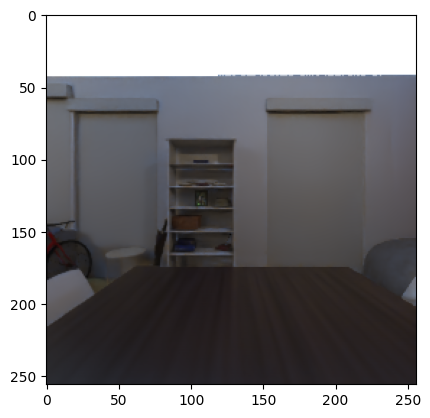

In [59]:
import matplotlib.pyplot as plt
cam_ids = ['base_camera', 'fetch_head', 'fetch_right_arm_camera', 'fetch_left_arm_camera']


rgba_pixels = obs['sensor_data']['fetch_head']['Color']
plt.imshow(rgba_pixels.cpu().squeeze(0).numpy())

In [ ]:

#joint values
obs['agent']['qpos']
env.get_state_dict()



/home/koepf/miniconda3/envs/vltest/lib/python3.12/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_state_dict to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_state_dict` for environment variables or `env.get_wrapper_attr('get_state_dict')` that will search the reminding wrappers.
  logger.warn(


{'actors': {'scs-[0]_objects/frl_apartment_kitchen_utensil_06-0': tensor([[-2.3697e+00, -4.9846e-01,  9.9172e-01,  7.0711e-01,  7.0711e-01,
            9.3132e-09, -3.7253e-09,  0.0000e+00,  0.0000e+00, -4.9050e-01,
            0.0000e+00,  0.0000e+00,  0.0000e+00]]),
  'scs-[0]_objects/frl_apartment_sofa-1': tensor([[ 3.9459e+00, -1.7796e+00,  4.3755e-01,  5.0233e-01,  5.0233e-01,
            4.9766e-01,  4.9766e-01,  5.6389e-06, -5.1174e-05, -7.9654e-05,
            6.9765e-05,  1.6465e-04,  4.6349e-06]]),
  'scs-[0]_objects/frl_apartment_bin_02-2': tensor([[-2.1218e+00,  4.7640e-01,  4.2163e-01,  5.0016e-01,  4.9984e-01,
            5.0006e-01,  4.9994e-01, -4.4969e-03,  1.0290e-02, -1.3982e-03,
           -2.8552e-02, -1.2573e-02, -2.4402e-03]]),
  'scs-[0]_objects/frl_apartment_bin_03-3': tensor([[-2.2065e+00,  1.7315e+00,  3.3798e-01,  5.0026e-01,  4.9979e-01,
            5.0001e-01,  4.9994e-01, -1.0357e-02,  9.7235e-03,  7.4782e-04,
           -3.3652e-02, -2.6703e-02, -1.6360e

In [7]:
# step_counter = 0
# while True:
#     obs, reward, terminated, truncated, info = env.step(action)
#         step_counter += 1
    
#     if render_mode is not None:
#         env.render()
        
#     if render_mode is None or render_mode != "human":
#         if (terminated | truncated).any():
#             break
